<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2026notebooks/2026_1002chihaya_Transformer_LSTM_SRN_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 百人一首 上の句→下の句 変換: 公式PyTorch実装のみによる Transformer / LSTM / SRN 比較


比較実験：隠れ次元数一致（少=16／中=32／多=64）× シードを変えて複数回実行 20 回


## 1. 環境準備

In [1]:
import sys, subprocess

try:
    import torch
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch'], check=True)
    import torch

try:
    import japanize_matplotlib
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'japanize_matplotlib'], check=True)

print('torch', torch.__version__)


torch 2.11.0+cpu


## 2. データ読み込み

`chihaya.json` を読み込みひらがな文字ベースでトークン化。語彙数 V=52（48 種のひらがな＋特殊トークン 4 つ）


In [ ]:
from collections import OrderedDict
import os
import sys
import numpy as np
import json
chihaya_fname = 'chihaya.json'

if os.path.exists(chihaya_fname):
    # カレントディレクトリに 'chihaya.json' があれば，その情報を読み込む
    with open(chihaya_fname, 'r') as fp:
        chihaya = OrderedDict(json.load(fp))
else:
    # カレントディレクトリに 'chihaya.json' がなければ，ダウンロード
    import requests
    url = 'http://www.diana.dti.ne.jp/~fujikura/List/List.html'
    page = requests.get(url)  # url から内容を取得

    from bs4 import BeautifulSoup
    soup = BeautifulSoup(page.content, 'html.parser')
    # print(soup.prettify()) 確認のため表示
    body = list(soup.children)[0]

    chihaya = OrderedDict()
    i = 1
    m = []
    # 最初と最後は百人一首の歌と無関係なため [1:-1] で除外
    for p in body.getText().split()[1:-1]:
        mod = i % 7

        if mod == 0:
            chihaya[N] = m
            print(chihaya[N])
            m = []
        elif mod == 1:
            N = int(p)
        elif mod > 2:
            m.append(p)
        i += 1

    # 後日のために，'chihaya.json' を書き出す
    # if not os.path.exists(chihaya_fname):
    #     with open(chihaya_fname, 'w') as fp:
    #         json.dump(chihaya, fp, ensure_ascii=False, indent=4)

chihaya_chrs = OrderedDict()
for k, v in chihaya.items():

    # v[0]:漢字上の句，v[1]:漢字下の句，v[2]:ひらがな上の句，v[3]:ひらがな下の句
    for ku in [v[2], v[3]]:
        for ch in ku:
            if not ch in chihaya_chrs:
                chihaya_chrs[ch] = 1
            else:
                chihaya_chrs[ch] += 1

chars = set()
for v in chihaya.values():
    chars.update(v[2])
    chars.update(v[3])

chihaya_tokens = ['<PAD>', '<SOS>', '<EOS>', '<UNK>'] + sorted(chars)
idx2tkn = {i: t for i, t in enumerate(chihaya_tokens)}
tkn2idx = {t: i for i, t in enumerate(chihaya_tokens)}
V = len(chihaya_tokens)
PAD, SOS, EOS, UNK = 0, 1, 2, 3

print('poems:', len(chihaya), ' V =', V)

def encode(s):
    return [SOS] + [tkn2idx.get(c, UNK) for c in s] + [EOS]

pairs = [(encode(val[2]), encode(val[3])) for val in chihaya.values()]

In [4]:
print(f'chihaya_tokens:{chihaya_tokens}')

chihaya_tokens:['<PAD>', '<SOS>', '<EOS>', '<UNK>', 'あ', 'い', 'う', 'え', 'お', 'か', 'き', 'く', 'け', 'こ', 'さ', 'し', 'す', 'せ', 'そ', 'た', 'ち', 'つ', 'て', 'と', 'な', 'に', 'ぬ', 'ね', 'の', 'は', 'ひ', 'び', 'ふ', 'へ', 'ほ', 'ま', 'み', 'む', 'め', 'も', 'や', 'ゆ', 'よ', 'ら', 'り', 'る', 'れ', 'ろ', 'わ', 'ゐ', 'ゑ', 'を']


In [ ]:
for N in [1,2,4,8,16,32,64,100]:
     print(N, chihaya[N])

In [ ]:
import operator
import matplotlib.pyplot as plt
import japanize_matplotlib

count = {}
for k, v in chihaya.items():
    kami, shimo = v[2], v[3]
    for ch in kami+shimo:
        #print(ch, end=" ")
        if ch in count:
            count[ch] += 1
        else:
            count[ch] = 1
count_sorted = sorted(count.items(), key=operator.itemgetter(1), reverse=True)
plt.figure(figsize=(14,4))
N = np.array([x[1] for x in count.items()]).sum()
plt.bar(range(len(count_sorted)), [x[1]/N for x in count_sorted])
plt.xticks(ticks=range(len(count_sorted)), labels=[c[0] for c in count_sorted])
plt.title('百人一首の文字頻度')
plt.show()

## 3. モデル定義

- **Transformer**: `nn.Transformer` を Embedding + 正弦波位置符号化 + 出力線形層で
  ラップした `Seq2SeqTransformerOfficial`。causal mask は
  `nn.Transformer.generate_square_subsequent_mask` を使用。
- padding mask も `src_key_padding_mask` / `tgt_key_padding_mask` / `memory_key_padding_mask` として
  明示的に渡す（bool マスクは `generate_square_subsequent_mask` の float 加算マスクと
  型を揃えるため float 加算マスクに変換している。型が混在すると PyTorch が非推奨警告を出す）。
- **LSTM** / **SRN**: `nn.LSTM` / `nn.RNN` ベースの Seq2Seq


3 モデルとも `hidden_dim` を直接 `d_model` / `n_hid` として指定することで「隠れ次元数一致」比較の軸を揃える。


In [8]:
import math
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader


class ChihayaDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        return torch.tensor(src, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_pad = pad_sequence(srcs, batch_first=True, padding_value=PAD)
    tgt_pad = pad_sequence(tgts, batch_first=True, padding_value=PAD)
    return src_pad, tgt_pad

def make_dataloader(pairs, batch_size=1, shuffle=True):
    return DataLoader(ChihayaDataset(pairs), batch_size=batch_size,
                       shuffle=shuffle, collate_fn=collate_fn)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=64):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class Seq2SeqTransformerOfficial(nn.Module):
    """torch.nn.Transformer"""
    def __init__(self, vocab_size, d_model, nhead=4, num_layers=1, dim_feedforward=None,
                 dropout=0.0, max_len=64):
        super().__init__()
        dim_feedforward = dim_feedforward or d_model
        self.src_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.tgt_embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.out = nn.Linear(d_model, vocab_size)

    @staticmethod
    def _float_padding_mask(bool_mask):
        m = torch.zeros_like(bool_mask, dtype=torch.float32)
        m.masked_fill_(bool_mask, float('-inf'))
        return m

    def forward(self, src, tgt, teacher_forcing=True):
        src_key_padding_mask = self._float_padding_mask(src == PAD)
        if teacher_forcing:
            tgt_in = tgt[:, :-1]
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_in.size(1)).to(src.device)
            tgt_key_padding_mask = self._float_padding_mask(tgt_in == PAD)
            src_emb = self.pos_encoder(self.src_embedding(src))
            tgt_emb = self.pos_encoder(self.tgt_embedding(tgt_in))
            out = self.transformer(
                src_emb, tgt_emb, tgt_mask=tgt_mask,
                src_key_padding_mask=src_key_padding_mask,
                tgt_key_padding_mask=tgt_key_padding_mask,
                memory_key_padding_mask=src_key_padding_mask)
            return self.out(out)
        else:
            T = tgt.size(1)
            src_emb = self.pos_encoder(self.src_embedding(src))
            memory = self.transformer.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)
            inp = tgt[:, 0:1]
            outputs = []
            for _ in range(T - 1):
                tgt_emb = self.pos_encoder(self.tgt_embedding(inp))
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(inp.size(1)).to(src.device)
                dec_out = self.transformer.decoder(
                    tgt_emb, memory, tgt_mask=tgt_mask,
                    memory_key_padding_mask=src_key_padding_mask)
                logit = self.out(dec_out[:, -1:, :])
                outputs.append(logit)
                inp = torch.cat([inp, logit.argmax(-1)], dim=1)
            return torch.cat(outputs, dim=1)


class Seq2SeqLSTM(nn.Module):
    def __init__(self, vocab_size, n_hid, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, n_hid, padding_idx=PAD)
        self.encoder = nn.LSTM(n_hid, n_hid, n_layers, batch_first=True)
        self.decoder = nn.LSTM(n_hid, n_hid, n_layers, batch_first=True)
        self.out = nn.Linear(n_hid, vocab_size)

    def forward(self, src, tgt, teacher_forcing=True):
        emb_src = self.embedding(src)
        _, (h, c) = self.encoder(emb_src)
        T = tgt.size(1)
        if teacher_forcing:
            emb_tgt = self.embedding(tgt[:, :-1])
            dec_out, _ = self.decoder(emb_tgt, (h, c))
            return self.out(dec_out)
        outputs, inp, hx = [], tgt[:, 0:1], (h, c)
        for _ in range(T - 1):
            emb = self.embedding(inp)
            dec_out, hx = self.decoder(emb, hx)
            logit = self.out(dec_out)
            outputs.append(logit)
            inp = logit.argmax(-1)
        return torch.cat(outputs, dim=1)


class Seq2SeqSRN(nn.Module):
    def __init__(self, vocab_size, n_hid, n_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, n_hid, padding_idx=PAD)
        self.encoder = nn.RNN(n_hid, n_hid, n_layers, batch_first=True, nonlinearity='tanh')
        self.decoder = nn.RNN(n_hid, n_hid, n_layers, batch_first=True, nonlinearity='tanh')
        self.out = nn.Linear(n_hid, vocab_size)

    def forward(self, src, tgt, teacher_forcing=True):
        emb_src = self.embedding(src)
        _, h = self.encoder(emb_src)
        T = tgt.size(1)
        if teacher_forcing:
            emb_tgt = self.embedding(tgt[:, :-1])
            dec_out, _ = self.decoder(emb_tgt, h)
            return self.out(dec_out)
        outputs, inp, hx = [], tgt[:, 0:1], h
        for _ in range(T - 1):
            emb = self.embedding(inp)
            dec_out, hx = self.decoder(emb, hx)
            logit = self.out(dec_out)
            outputs.append(logit)
            inp = logit.argmax(-1)
        return torch.cat(outputs, dim=1)


def build_model(arch, hidden_dim, vocab_size=V):
    if arch == 'Transformer':
        return Seq2SeqTransformerOfficial(
            vocab_size,
            d_model=hidden_dim,
            nhead=4,
            num_layers=1,
            dim_feedforward=hidden_dim,
            dropout=0.0,
            max_len=64)
    elif arch == 'LSTM':
        return Seq2SeqLSTM(
            vocab_size,
            hidden_dim)
    elif arch == 'SRN':
        return Seq2SeqSRN(
            vocab_size,
            hidden_dim)
    raise ValueError(arch)


## 4. 検証: causal mask とパディングマスクが正しく機能しているか

実装を信頼する前に、以下を確認する:
1. 教師強制あり／なし双方で出力 shape が期待通りか。
2. **causal mask**: デコーダのある時刻の出力が、それより未来の正解トークンに
   依存していないか（未来をカンニングしていないか）。
3. パディングを含むバッチでもエラーなく動作するか。


In [9]:
torch.manual_seed(0)

for arch in ['Transformer', 'LSTM', 'SRN']:
    model = build_model(arch, 32)
    src = torch.randint(4, V, (2, 5))
    tgt = torch.randint(4, V, (2, 6))
    for tf in [True, False]:
        out = model(src, tgt, teacher_forcing=tf)
        out.sum().backward()
        model.zero_grad()
        assert out.shape == (2, tgt.size(1) - 1, V)
    print(f"{arch}: shape/backward OK, params={sum(p.numel() for p in model.parameters())}")

# causal mask 確認（Transformer）
model = build_model('Transformer', 32).eval()
src = torch.randint(4, V, (1, 5))
tgt = torch.randint(4, V, (1, 6))
with torch.no_grad():
    out1 = model(src, tgt, teacher_forcing=True)
    tgt2 = tgt.clone()
    tgt2[0, -1] = (tgt2[0, -1] + 1) % V
    out2 = model(src, tgt2, teacher_forcing=True)
    same_prefix = torch.allclose(out1[:, :-1], out2[:, :-1], atol=1e-5)
print("causal mask (未来非参照) 確認:", same_prefix)
assert same_prefix
print("全テスト成功")


Transformer: shape/backward OK, params=22388
LSTM: shape/backward OK, params=20276
SRN: shape/backward OK, params=7604
causal mask (未来非参照) 確認: True
全テスト成功


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


## 5. 学習・評価ループ


In [10]:
import random
import numpy as np

def init_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def run_once(arch, hidden_dim, seed, pairs, epochs=6, batch_size=1,
             teacher_forcing=True, device='cpu'):
    init_seed(seed)
    model = build_model(arch, hidden_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.98), eps=1e-9)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)
    loader = make_dataloader(pairs, batch_size=batch_size, shuffle=True)

    final_acc, final_loss = 0.0, 0.0
    for epoch in range(epochs):
        model.train()
        total_loss, total_tok, correct = 0.0, 0, 0
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            optimizer.zero_grad()
            logits = model(src, tgt, teacher_forcing=teacher_forcing)
            target = tgt[:, 1:]
            L = min(logits.size(1), target.size(1))
            logits, target = logits[:, :L], target[:, :L]
            loss = criterion(logits.reshape(-1, logits.size(-1)), target.reshape(-1))
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * target.numel()
            pred = logits.argmax(-1)
            mask = target != PAD
            correct += ((pred == target) & mask).sum().item()
            total_tok += mask.sum().item()

        final_loss = total_loss / max(total_tok, 1)
        final_acc = correct / max(total_tok, 1) * 100

    n_params = sum(p.numel() for p in model.parameters())
    return {'arch': arch, 'hidden_dim': hidden_dim, 'seed': seed,
            'n_params': n_params, 'final_loss': final_loss, 'final_acc': final_acc}


## 6. 実験実行: 隠れ次元数 3 水準 × シード N 回

乱数のシードを変更して N 回反復することで初期値による違いが結果に与える影響を見積もる。
EPOCHS = 20 は繰り返し学習する回数である。

実測 N_SEEDS = 3, EPOCHS = 20 で 330 秒程度

In [14]:
import time

hidden_dims = {'少': 16, '中': 32, '多': 64}
architectures = ['Transformer', 'LSTM', 'SRN']
N_SEEDS = 20
EPOCHS = 6

N_SEEDS = 3
EPOCHS = 20
results = []
t0 = time.time()
for level, hd in hidden_dims.items():
    for arch in architectures:
        accs = []
        for seed in range(N_SEEDS):
            r = run_once(arch, hd, seed, pairs, epochs=EPOCHS, batch_size=4)
            accs.append(r['final_acc'])
            results.append(r)
        print(f"{level}({hd:3d}) {arch:11s}: acc={np.mean(accs):6.2f}% "
              f"(min={min(accs):6.2f} max={max(accs):6.2f}) n_params={r['n_params']}")
elapsed = time.time() - t0
print(f"\n合計実行時間: {elapsed:.1f} 秒 ({len(hidden_dims)*len(architectures)*N_SEEDS} 回実行)")


少( 16) Transformer: acc= 19.50% (min= 17.25 max= 22.67) n_params=7124
少( 16) LSTM       : acc= 14.41% (min= 14.01 max= 14.87) n_params=6068
少( 16) SRN        : acc= 15.51% (min= 15.14 max= 15.80) n_params=2804
中( 32) Transformer: acc= 39.13% (min= 37.61 max= 40.91) n_params=22388
中( 32) LSTM       : acc= 22.08% (min= 21.55 max= 23.07) n_params=20276
中( 32) SRN        : acc= 22.32% (min= 22.08 max= 22.67) n_params=7604
多( 64) Transformer: acc= 88.01% (min= 85.66 max= 92.20) n_params=77492
多( 64) LSTM       : acc= 39.92% (min= 39.00 max= 40.71) n_params=73268
多( 64) SRN        : acc= 36.64% (min= 36.09 max= 37.01) n_params=23348

合計実行時間: 95.3 秒 (27 回実行)


## 7. 結果の可視化

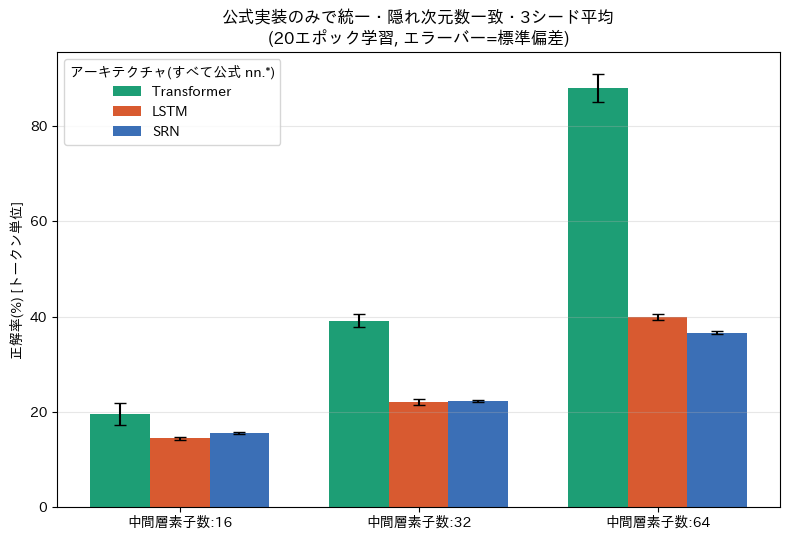


各セルのパラメータ数:
  少(hid= 16) Transformer:   7124 params
  少(hid= 16) LSTM       :   6068 params
  少(hid= 16) SRN        :   2804 params
  中(hid= 32) Transformer:  22388 params
  中(hid= 32) LSTM       :  20276 params
  中(hid= 32) SRN        :   7604 params
  多(hid= 64) Transformer:  77492 params
  多(hid= 64) LSTM       :  73268 params
  多(hid= 64) SRN        :  23348 params


In [15]:
import matplotlib.pyplot as plt
import japanize_matplotlib

levels = ['少', '中', '多']
hd_map = {16: '少', 32: '中', 64: '多'}
colors = {'Transformer': '#1D9E75', 'LSTM': '#D85A30', 'SRN': '#3B6FB6'}

data = {a: {l: [] for l in levels} for a in architectures}
nparams = {a: {l: None for l in levels} for a in architectures}
for r in results:
    lvl = hd_map[r['hidden_dim']]
    data[r['arch']][lvl].append(r['final_acc'])
    nparams[r['arch']][lvl] = r['n_params']

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(levels))
width = 0.25
for i, a in enumerate(architectures):
    means = [np.mean(data[a][l]) for l in levels]
    stds = [np.std(data[a][l]) for l in levels]
    ax.bar(x + (i-1)*width, means, width, yerr=stds, capsize=4, label=a, color=colors[a])

ax.set_xticks(x)
ax.set_xticklabels([f"中間層素子数:{hidden_dims[l]}" for l in levels])
#ax.set_xticklabels([f"{l}\n(hid={hidden_dims[l]})" for l in levels])
ax.set_ylabel('正解率(%) [トークン単位]')
ax.set_title(f'公式実装のみで統一・隠れ次元数一致・{N_SEEDS}シード平均\n({EPOCHS}エポック学習, エラーバー=標準偏差)')
ax.legend(title='アーキテクチャ(すべて公式 nn.*)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n各セルのパラメータ数:')
for l in levels:
    for a in architectures:
        print(f"  {l}(hid={hidden_dims[l]:3d}) {a:11s}: {nparams[a][l]:6d} params")


## 8. 前回（CDP_ja.Transformer 版）との差異と解釈

- Transformer > SRN = LSTM という傾向を確認すること
